# 04 · Modelo CNN (solo imágenes)

**Objetivo:** Entrenar una red neuronal convolucional usando únicamente las imágenes dermatoscópicas 28×28 RGB.

**Datos de entrada:** `../data/raw/hnmist_28_28_RGB.csv`, `../data/raw/HAM10000_metadata.csv`

**Resultado esperado:** Modelo guardado en `../models/cnn_model.h5` con ~74% de accuracy en test.

**Arquitectura:** 3 bloques Conv2D + MaxPooling → Flatten → Dense(256) + Dropout → Softmax(7).

# Modelo 2: CNN 
Vamos a entrenar aquí un modelo de red neuronal convolucional. Gracias a la convolución, nuestro modelo va a ser capaz de observar señales en nuestras imágenes, como pueden ser bordes, cambios de color muy bruscos... etc y así analizar patrones que se puedan dar en ellas. 
Para crear este modelo, nuestro patrón será crear una secuencia de capas donde iremos incrementando el número de neuronas (32, 64, 128...) y aplicando una capa Batchpooling entre ellas para normalizar esos datos. 
Después, tendremos que usar una capa Flatten para aplanar los datos, y a partir de ahí, Dense para tomar la decisión final y Dropout para "olvidar" las muestras anteriores y así no tener overfitting. 
En nuestra última capa densa, eso sí, utilizamos la función de activación softmax, ya que tiene que decidir entre más de 2 posibilidades
Después de una primera prueba, hemos visto que nuestro modelo empezaba a tener overfitting a partir de la epoch 10/12 aproximadamente, por lo que hemos configurado también un early stopper para que el modelo no siga entrenando y aprendiendo de las imágenes, ya que si las aprende demasiado bien, el resultado puede ser negativo, ya que respondería muy bien a las imágenes con las que ha aprendido, pero nada bien a las imágenes nuevas que podamos mostrarle 

## Carga de datos, preprocesado y entrenamiento

La CNN aprende representaciones espaciales de las imágenes directamente de los píxeles. A diferencia del modelo tabular, no requiere feature engineering manual.

**Hiperparámetros clave:**
- `batch_size=32`: balance entre estabilidad del gradiente y velocidad.
- `EarlyStopping(patience=5, restore_best_weights=True)`: detiene el entrenamiento cuando la val_loss deja de mejorar y recupera los pesos del mejor epoch, evitando overfitting.
- Filtros crecientes (32→64→128): las capas iniciales detectan bordes simples; las posteriores combinan esas features en patrones más complejos.

Columnas del dataset: Index(['pixel0000', 'pixel0001', 'pixel0002', 'pixel0003', 'pixel0004',
       'pixel0005', 'pixel0006', 'pixel0007', 'pixel0008', 'pixel0009'],
      dtype='object')
Epoch 1/30


c:\Users\rammu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6416 - loss: 1.2358
Epoch 1: val_loss improved from None to 0.98788, saving model to mejor_modelo_early_fusion.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.6766 - loss: 1.1132 - val_accuracy: 0.6837 - val_loss: 0.9879
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6832 - loss: 1.0167
Epoch 2: val_loss improved from 0.98788 to 0.92141, saving model to mejor_modelo_early_fusion.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.6862 - loss: 0.9815 - val_accuracy: 0.6837 - val_loss: 0.9214
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6918 - loss: 0.9440
Epoch 3: val_loss improved from 0.92141 to 0.87783, saving model to mejor_modelo_early_fusion.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.6897 - loss: 0.9402 - val_accuracy: 0.6837 - val_loss: 0.8778
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6927 - loss: 0.8977
Epoch 4: val_loss improved

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7520 - loss: 0.7140
Test accuracy: 0.7520


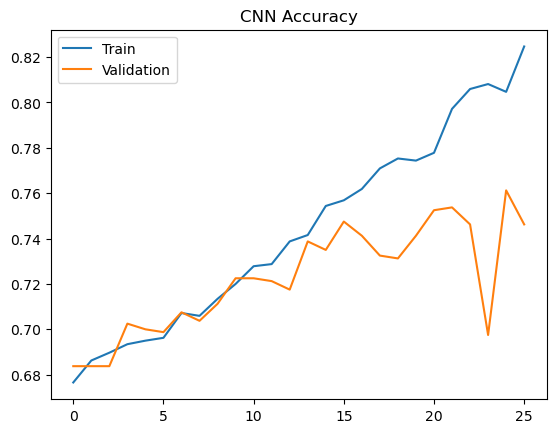

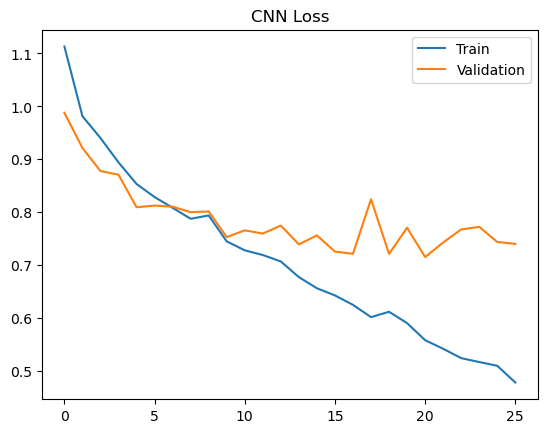

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import os
import glob
import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Cargar datos
# CSV de imágenes
path = r"../data/raw/hnmist_28_28_RGB.csv"
df = pd.read_csv(path)
print("Columnas del dataset:", df.columns[:10])

# Metadata
metadata = pd.read_csv(r"../data/raw/HAM10000_metadata.csv")

# Etiquetas
y = metadata['dx'].values[:len(df)]
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
num_classes = y_onehot.shape[1]

# Preprocesamiento tabular
tabular_data = metadata[['age', 'sex', 'localization']][:len(df)]
tabular_data = pd.get_dummies(tabular_data, columns=['sex', 'localization'], drop_first=True)
tabular_data['age'] = tabular_data['age'] / tabular_data['age'].max()
tabular_features = tabular_data.values.astype(np.float32)

#  Preprocesamiento imágenes
X_img = df.values.astype(np.float32).reshape(-1, 28, 28, 3)
X_img /= 255.0

X_tab = tabular_features
y_all = y_onehot

#  Convertir labels a one-hot 
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)
y_onehot = to_categorical(y_encoded)

# Dividir en train/test  
X_train, X_test, y_train, y_test = train_test_split(
    images, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded)
input_shape = (96, 96, 3)
num_classes = y_train.shape[1]

model = Sequential()
model.add(Conv2D(32, kernel_size = (3,3), activation='relu', padding='same', input_shape=input_shape, strides = (1,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size = (3,3), activation='relu', padding='same', input_shape=input_shape, strides = (1,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128, kernel_size = (3,3), activation='relu', padding='same', input_shape=input_shape, strides = (1,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(256, kernel_size = (3,3), activation='relu', padding='same', input_shape=input_shape, strides = (1,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compilar  
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])

checkpoint = ModelCheckpoint(
    "../models/mejor_modelo_early_fusion.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1)
#entrenamos el modelo

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop, checkpoint])
#guardamos el modelo
model.save('../models/cnn_model.h5')
# Evaluación en test
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
#Graficamos los resultados de accuracy y loss
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Modelo 2D, conclusiones:
Este ha sido nuestro primer modelo 2D!
Como vemos, la convolución nos ha permitido alcanzar un valor de 0.74 aprox, algo mejor que nuestro modelo tabular. Como ya expliqué en la introducción de este modelo, en el gráfico observamos que el overfitting iba a empezar a suceder a partir de estos valores. por eso, hemos configurado Earlystopping con 'restore_best_weights'=True, de manera que el modelo que tenemos corresponde a la mejor epoch donde el modelo aún aprendía. 
